# Part 1: Data Hygiene & Pipeline Setup


## Getting rid of the Garbage
Before trying to answer questions about sentiment or framing, we must ensure our dataset is clean. 
Web scraping is often messy: it captures HTML tags, encoding errors, and video or ad captions.

**Our Goal in this section:**
1.  **Standardize:** Fix encoding issues (e.g., turning `NicolÃ¡s` back into `Nicolás`).
2.  **Clean:** Remove URL artifacts and excessive whitespace.
3.  **Filter:** Remove duplicates and "short" articles (under 50 words) that lack sufficient semantic content.
4.  **Preserve:** We will **NOT** remove stopwords or lowercase the text yet. Cf our cours, preprocessing is *task-specific*. For exp, advanced models (like BERT) and Named Entity Recognition (NER) need capitalization and sentence structure to work correctly.


In [1]:
# IMPORTS & SETUP


# Standard Data Science Imports
import pandas as pd
import numpy as np
import re  # Regular Expressions > used for pattern matching

# NLP libs
!pip install ftfy
import ftfy  # "Fix Text For You" > used for fixing scraped encoding errors

# Visualization 
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration to make pandas display readable
pd.set_option('display.max_colwidth', 150)  # Max characters shown per cell

print("Libraries Imported Successfully.")


Libraries Imported Successfully.


In [2]:
# LOAD & INSPECT

### IF YOU RUN ON YOUR OWN COMPUTER


user_path='/Users/alizeearchereau/Desktop/ALIZEE/1- EDHEC/5-M2 (MSc)/13--Natural Language Processing/group project/final/'              # TO REPLACE WITH YOURS if you want to run the code
FILE_PATH = user_path+"maduro_us_articles_FINAL_merged.csv" 

try:
    df = pd.read_csv(FILE_PATH)
    print(f"\n-- Raw Data Loaded --")
    print(f"Total Rows: {len(df)}")
    print(f"Columns: {list(df.columns)}")
    
    # Remove any missing values
    missing_content = df['content'].isna().sum()
    if missing_content > 0:
        print(f"Warning: Found {missing_content} rows with missing content. Dropping them...")
        df = df.dropna(subset=['content', 'ideology'])
        
except FileNotFoundError:
    print(f"Error: Could not find {FILE_PATH}. Please check the file name.")



-- Raw Data Loaded --
Total Rows: 187
Columns: ['source', 'ideology', 'title', 'content', 'date', 'url', 'scraped_at', 'parsed_date']


In [3]:
### IF YOU RUN ON GOOGLE COLLAB
"""
from google.colab import files
uploaded = files.upload()   

import io
filename = next(iter(uploaded))
df = pd.read_csv(io.BytesIO(uploaded[filename]))      # UPLOAD THE DATA HERE maduro_us_articles_FINAL_merged.csv

print(f"\n-- Raw Data Loaded --")
print(f"Total Rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
    
# Remove any missing values
missing_content = df['content'].isna().sum()
if missing_content > 0:
    print(f"Warning: Found {missing_content} rows with missing content. Dropping them...")
    df = df.dropna(subset=['content', 'ideology'])

"""

'\nfrom google.colab import files\nuploaded = files.upload()   \n\nimport io\nfilename = next(iter(uploaded))\ndf = pd.read_csv(io.BytesIO(uploaded[filename]))      # UPLOAD THE DATA HERE maduro_us_articles_FINAL_merged.csv\n\nprint(f"\n-- Raw Data Loaded --")\nprint(f"Total Rows: {len(df)}")\nprint(f"Columns: {list(df.columns)}")\n\n# Remove any missing values\nmissing_content = df[\'content\'].isna().sum()\nif missing_content > 0:\n    print(f"Warning: Found {missing_content} rows with missing content. Dropping them...")\n    df = df.dropna(subset=[\'content\', \'ideology\'])\n\n'

In [4]:
# CLEANING PIPELINE


def clean_article_text(text):
    """
    The generic Cleaning Function.
    Input: Raw string
    Output: Cleaned string (human-readable)
    """
    if not isinstance(text, str):
        return ""       # if it's a number or anything else we don't take it into account
    
    # Fix Mojibake (Encoding glitches)
    # eg turning "Floridaâ€™s" into "Florida's" automatically
    text = ftfy.fix_text(text)
    
    # Remove URLs (http://...) and common scraping artifacts
    text = re.sub(r'http\S+', '', text)  # Remove links
    text = re.sub(r'www\.\S+', '', text) # Remove www links
    text = re.sub(r'pic\.twitter\.\S+', '', text) # Remove twitter image links
    
    # Remove meaningless text often found in news scrapers
    # We use regex to match these specific phrases case-insensitively
    artifacts = [
        # Standard cleanup
        r'IMAGE DISTRIBUTED FOR', 
        r'See the latest news', 
        r'Copyright \d{4}',
        r'All rights reserved',
        r'Follow us on',
        r'Click here',
        r'Subscribe to',
        r'advertisement',
        
        # UI noise: things picked up by the scraped that we don't want
        r'saved list',
        r'reached maximum',
        r'number items',
        r'saved items',
        r'items add',
        r'save article',
        r'article later',
        r'promo code',
        
        # Editorial / metadata / social media noise
        r'editor\s?note',
        r'editor note'
        r'post live',
        r'follow post',
        r'\d+ minutes'
    ]
    
    # Join them into one giant OR pattern for speed
    # \b ensures we match whole words/phrases
    pattern = r'|'.join(artifacts)
    text = re.sub(pattern, '', text, flags=re.IGNORECASE)

    # Standardize Whitespace
    # Replaces newlines (\n) and tabs with a single space
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

print("\n-- Applying Cleaning Pipeline --")
# Create a new column 'clean_text' so we can compare with original if needed
df['clean_text'] = df['content'].apply(clean_article_text)
print("Text cleaning complete.")


-- Applying Cleaning Pipeline --
Text cleaning complete.


In [5]:
# DEDUPLICATION & FILTERING


initial_count = len(df)

# 1. Deduplication
# Sometimes scrapers grab the same article from different URLs. 
# We remove rows where both Title and Content are identical.
df = df.drop_duplicates(subset=['title', 'clean_text'])
duplicates_removed = initial_count - len(df)

# 2. Length Filtering
# We calculate word count. 
df['word_count'] = df['clean_text'].apply(lambda x: len(str(x).split()))
# We set a threshold of 50 words. Reasoning: anything less than 50w long is likely a video caption, a tweet embedded in a page, or a scraper error.
short_article_threshold = 50
df_clean = df[df['word_count'] >= short_article_threshold].copy()
short_removed = len(df) - len(df_clean)

In [6]:
# FINAL REPORT & example of document


print("\n-- Data hygiene Report --")
print(f"Raw Articles:           {initial_count}")
print(f"Duplicates Removed:     {duplicates_removed}")
print(f"Short Articles (<{short_article_threshold}w):  {short_removed}")
print(f"\n-- Final Dataset --")
print(f"Number of Articles:     {len(df_clean)}")

print("\n-- Sample of Cleaned Text (First 200 chars) --")
print(df_clean['clean_text'].iloc[0][:200] + "...")



-- Data hygiene Report --
Raw Articles:           187
Duplicates Removed:     4
Short Articles (<50w):  1

-- Final Dataset --
Number of Articles:     182

-- Sample of Cleaned Text (First 200 chars) --
It was just like watching television. Huddled in a draped-off room at Mar-a-Lago around screens set up for his viewing pleasure — including, according to photos released by the White House, a live fee...


# Part 2: Lexical Analysis & The "Framing" Check

## Methodology: Bigrams instead of unigrams
Single words (unigrams) like "capture" or "operation" are often ambiguous. To understand *how* the media frames the event, we need to look at **Bigrams** (pairs of words) and **Trigrams** (triplets).

For example, we could observe:
*   "Maduro" - neutral.
*   "Dictator Maduro" - likely a Right-wing frame.
*   "President Maduro" - likely a Left-wing (or diplomatic) frame.

## The Metric: Fixing the Data Imbalance
Our dataset has more Left-wing articles than Right-wing articles. If we simply counted words, the Left would dominate the results.
To fix this, we use **Document Frequency (DF)**:
*   We calculate the **Percentage of articles** in which a phrase appears.
*   We look at $DF_{Right} - DF_{Left}$
*   For example, if a phrase appears in 60% of Right articles and 10% of Left articles, the score is **+50** (Strongly Right).

## Subtracting the Noise
Our initial analysis showed that "Twitter artifacts" and common entities (like "United States") were drowning out the interesting data.
We applied an **Aggressive Stopword Filter**. We remove:
1.  **Scraping Noise:** Words like "twitter", "pic", "video", "subscribe".
2.  **Common Entities:** "United States", "New York", "Washington".
3.  **Subject Matter:** "Maduro", "Venezuela" (because we know the articles are about them; we want to know *what* is being said about them).

## The Visualization Strategy
1.  **Difference Word Clouds:** Visualizing the gap.
    *   **Blue Cloud:** Phrases unique to the Left's framing.
    *   **Red Cloud:** Phrases unique to the Right's framing.
2.  **Divergence Bar Plot:** A ranked view of the top 15 most distinct phrases per ideology based on percentage difference.

In [7]:
# SETUP


from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Noise Filtering 
# We manually define words that are cluttering the analysis, going further than the first cleanup in Part 1
artifacts_and_entities = [
    # Scraping garbage & UI elements 
    'twitter', 'pic', 'com', 'http', 'https', 'www', 'href', 'images', 'image', 'getty', 
    'photo', 'photograph' 'video', 'watch', 'subscribe', 'saved', 'list', 'advertisement', 'caption'
    'copyright', 'rights', 'reserved', 'follow', 'share', 'facebook', 'posts',
    'later', 'add', 'save', 'remove', 'items', 'article', 'note', 'enjoy', 
    'reached', 'maximum', 'number', 'promo', 'code', 'vip', 'use', 'post', 'live',
    'editor', 'latest', 'flown', 'following','membership',

    # Media
    'nyc','truth','social',
    
    # Common Geographic/Political Entities (to reveal verbs/adjectives)
    'united', 'states', 'new', 'york', 'washington', 'venezuela', 'venezuelan', 
    'caracas', 'american', 'america', 'latin', 'miami', 'florida',
    
    # The subjects (We want to see how they are described, not just their names)
    'maduro', 'nicolas', 'nicolás', 'donald', 'trump', 'biden', 'joe', 'mr', 'mrs', 'ms'

    # Time info
    'minutes', 'saturday', 'morning', 'january', '2026', 'anytime',
    
    # Common verbs
    'said', 'told', 'reported', 'according', 'statement', 'press',

    # No good
    'caine', 'come'
]

# Combine with standard English stopwords
custom_stop_words = list(ENGLISH_STOP_WORDS.union(artifacts_and_entities))

def get_document_frequency(corpus, ngram_range=(2,2)):
    """
    Calculates the percentage of articles containing each n-gram.
    """
    # binary=True ensures we only count 1 if the word appears in the article, 
    # regardless of how many times it appears in that specific article.
    vec = CountVectorizer(
        ngram_range=ngram_range, 
        stop_words=custom_stop_words,
        binary=True,  
        min_df=3, # Must appear in at least 3 articles to count
        max_features=5000
    ).fit(corpus)
    
    # Sum up the "1s" to get how many articles contain the word
    bag_of_words = vec.transform(corpus)
    articles_with_word = bag_of_words.sum(axis=0) 
    
    words_freq = [
        (word, articles_with_word[0, idx]) 
        for word, idx in vec.vocabulary_.items()
    ]
    
    df_ngram = pd.DataFrame(words_freq, columns=['phrase', 'article_count'])
    
    # NORMALIZE: Divide by total number of articles in this group
    df_ngram['freq_percent'] = (df_ngram['article_count'] / len(corpus)) * 100
    return df_ngram



# CALCULATION


print("\n-- Generating Refined N-Grams based on Document Frequency... --")

left_corpus = df_clean[df_clean['ideology'] == 'Left']['clean_text']
right_corpus = df_clean[df_clean['ideology'] == 'Right']['clean_text']

# Generate Bigrams (2-word phrases)
df_left = get_document_frequency(left_corpus, ngram_range=(2,2))
df_right = get_document_frequency(right_corpus, ngram_range=(2,2))

# Merge the two datasets
comp_df = pd.merge(
    df_left[['phrase', 'freq_percent']], 
    df_right[['phrase', 'freq_percent']], 
    on='phrase', 
    how='outer', 
    suffixes=('_left', '_right')
).fillna(0)

# Calculate the Difference
# POSITIVE value = More common in RIGHT media
# NEGATIVE value = More common in LEFT media
comp_df['difference'] = comp_df['freq_percent_right'] - comp_df['freq_percent_left']



-- Generating Refined N-Grams based on Document Frequency... --



-- Generating Word Clouds... --


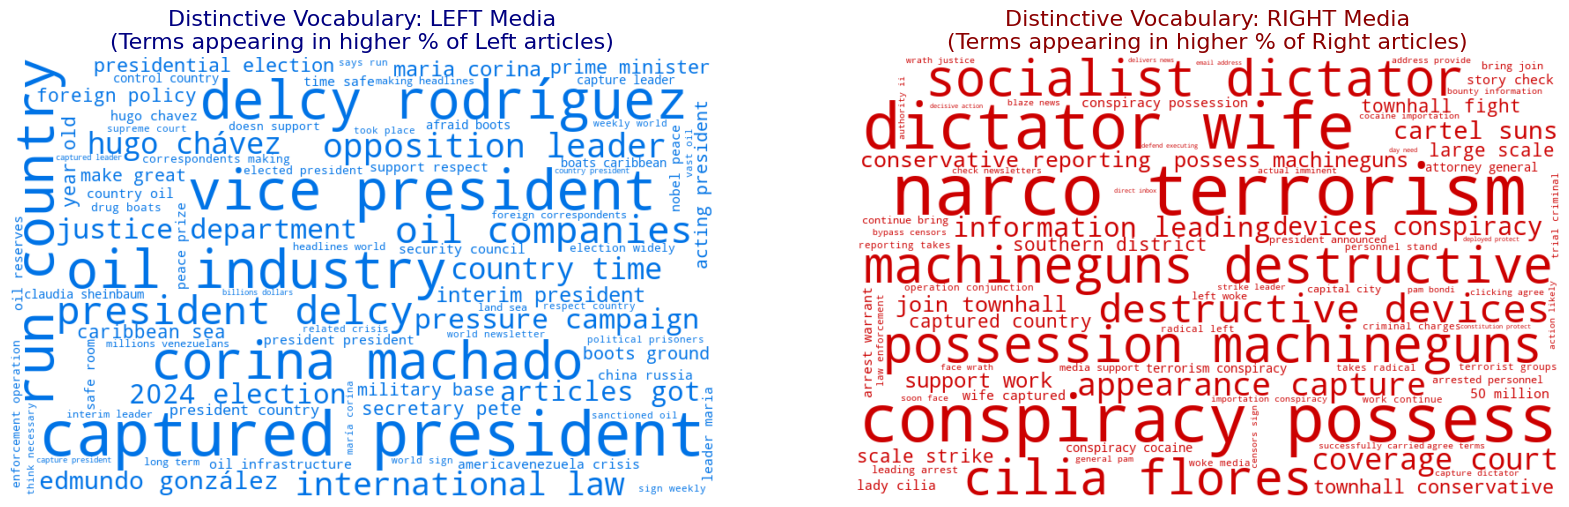

<Figure size 1200x1000 with 0 Axes>

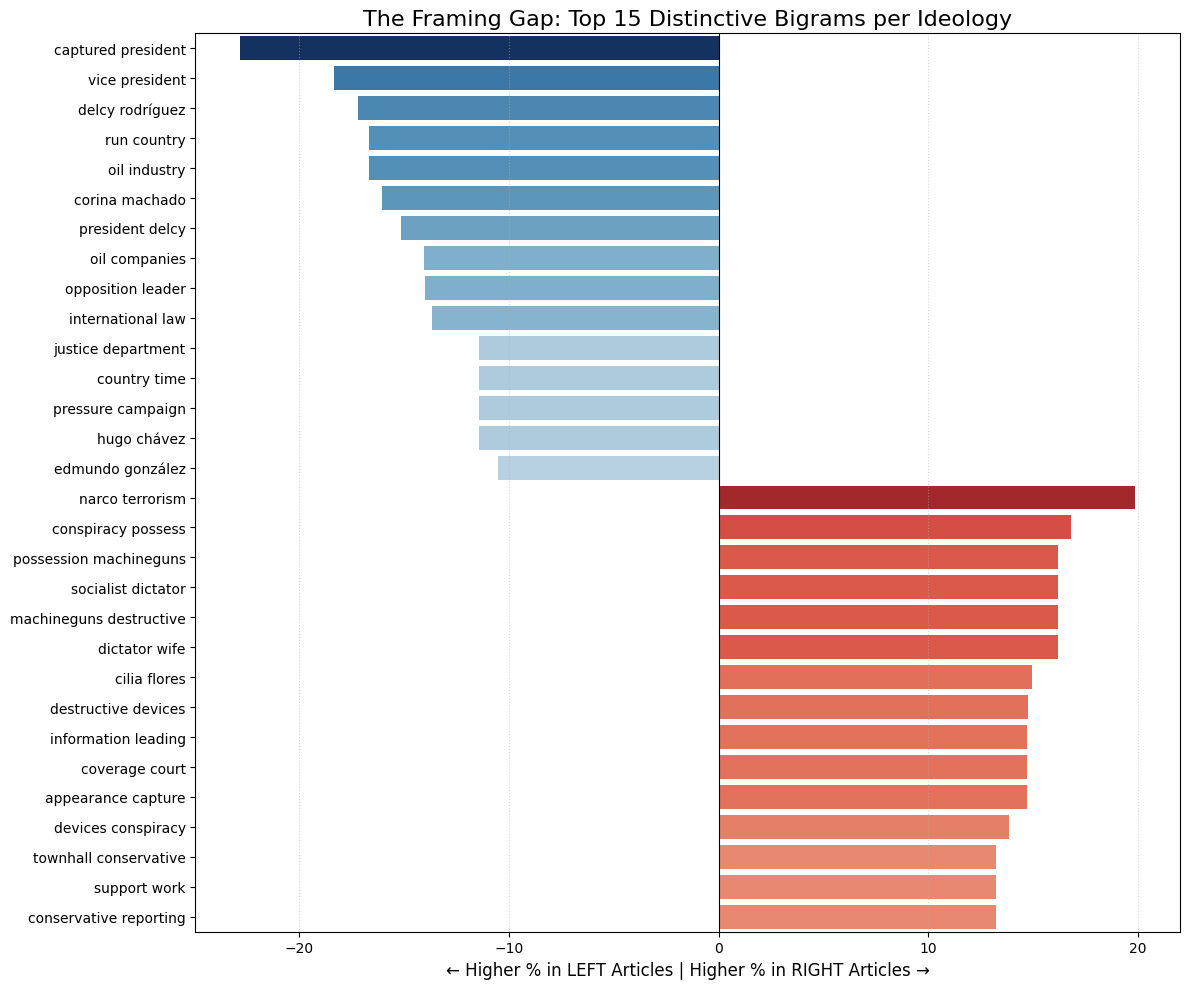

In [8]:
# VISUALIZATION 1 (WORD CLOUDS)


# Split into two dictionaries for the WordCloud generator
# Left: We take the negative values (Left skew), flip them to positive for the size
left_dict = comp_df[comp_df['difference'] < 0].set_index('phrase')['difference'].abs().to_dict()

# Right: We take the positive values (Right skew)
right_dict = comp_df[comp_df['difference'] > 0].set_index('phrase')['difference'].to_dict()

# Custom color functions
def color_func_blue(word, font_size, position, orientation, random_state=None, **kwargs):
    return "hsl(210, 100%, 45%)" # Blue hue

def color_func_red(word, font_size, position, orientation, random_state=None, **kwargs):
    return "hsl(0, 100%, 40%)" # Red hue

print("\n-- Generating Word Clouds... --")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Left Cloud
wc_left = WordCloud(background_color="white", width=800, height=500, max_words=80)
if left_dict:
    wc_left.generate_from_frequencies(left_dict)
    ax1.imshow(wc_left.recolor(color_func=color_func_blue), interpolation="bilinear")
ax1.set_title(f"Distinctive Vocabulary: LEFT Media\n(Terms appearing in higher % of Left articles)", fontsize=16, color='navy')
ax1.axis("off")

# Right Cloud
wc_right = WordCloud(background_color="white", width=800, height=500, max_words=80)
if right_dict:
    wc_right.generate_from_frequencies(right_dict)
    ax2.imshow(wc_right.recolor(color_func=color_func_red), interpolation="bilinear")
ax2.set_title(f"Distinctive Vocabulary: RIGHT Media\n(Terms appearing in higher % of Right articles)", fontsize=16, color='darkred')
ax2.axis("off")

plt.show()



# VISUALIZATION 2 (BAR PLOT)


# Filter for the most significant differences (Top 15 per side)
top_left = comp_df.sort_values('difference', ascending=True).head(15)
top_right = comp_df.sort_values('difference', ascending=False).head(15)
top_divergent = pd.concat([top_left, top_right])

plt.figure(figsize=(12, 10))

# Create gradient list: Map magnitude (abs value) to color intensity
norm = plt.Normalize(0, top_divergent['difference'].abs().max())
pal = [plt.cm.Blues(norm(abs(x))**1.5) if x < 0 else plt.cm.Reds(norm(x)**1.5) for x in top_divergent['difference']]
plt.figure(figsize=(12, 10))
sns.barplot(data=top_divergent, x='difference', y='phrase', hue='phrase', palette=pal)


plt.title('The Framing Gap: Top 15 Distinctive Bigrams per Ideology', fontsize=16)
plt.xlabel('← Higher % in LEFT Articles | Higher % in RIGHT Articles →', fontsize=12)
plt.ylabel('')
plt.axvline(0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()




## Interpretation

We successfully removed the noise. By normalizing based on **Article Percentage**, we removed the bias of the dataset size.

**How to read the Bar Plot:**
*   The **X-Axis** represents the *percentage point difference*.
*   Example: If "Narco Terrorism" has a value of +10, it means it appears in 10% *more* Right-wing articles than Left-wing articles.

**Analysis of the wordcloud and the bar plot:**
*   **Right-Wing (Red):** Focus a lot on criminality. Terms like **"conspiracy," "narco terrorism,"** and **"machineguns"** appear more here. This frames the capture as a successful law enforcement operation against a criminal.
*   **Left-Wing (Blue):** Focus on procedure and institutions. Terms involving **"international law,"** or **"opposition leader"** are more prevalent. This frames the event as a complex geopolitical maneuver with legal implications.


## Going further: Count of Unique Words

Another interesting thing to look at is the unique vocabulary usage in Left/Right-leaning articles to determine whether the narrative they carry rely on complex explanations or repetitive messaging.  
Because vocabulary growth is non-linear (Heaps' Law, according to the internet), we cannot simply divide by total word count to account for the class imbalance (we have more left-leaning article than right-leaning).  
The simplest method consists in randomly sampling as many article from the Left as we have from the Right.  


In [9]:
# 1. Tokenize per class
groups = df_clean.groupby('ideology')['clean_text'].apply(lambda x: " ".join(x).lower().split())

# 2. Find min size
min_len = groups.apply(len).min()

# 3. Sample & Count
vocab_counts_adj = groups.apply(
    lambda x: len(set(np.random.choice(x, min_len, replace=False)))
).reset_index(name='Unique Words (Adjusted)')

print(vocab_counts_adj)

  ideology  Unique Words (Adjusted)
0     Left                     7961
1    Right                     7218


## Interpretation 

Running this manually several times (to account for the random sampling), we observe that the unique count for the Left fluctuates around 8000, whereas it is 7200 for the Right.

So, the Left has a moderately larger lexicon (~1.14x).
This suggests a broader scope of topics or more varied terminology.
In contrast, the Right's slightly more concentrated vocabulary implies a higher repetition of specific terms or a narrower thematic focus. The difference is statistically present but too small to definitively claim a disparity in messaging complexity.

# Part 3: Sentiment Analysis (Baseline vs. Transformer)

We want to look at sentimental/affective framing to **determine whether ideological divergence manifests as differnece in emotional tone** or if, in contrary, it is only a matter of distinct surface-level vocabulary.  
To do this, we will use 2 approaches that have each their advantage and compare their results.

## Methodology: The "Lead Paragraph" Hypothesis
In journalism, the most emotionally charged and framing-heavy information is contained in the **Lede** (the first few paragraphs).
1.  **Baseline (VADER):** A lexicon-based model. It calculates sentiment by summing the "valence" of words. It is fast, but struggles with sarcasm or complex context (like political implications).
2.  **Transformer (RoBERTa):** A Transformer model fine-tuned on sentiment. It understands context (e.g., "The plan was *not* bad").
    *   *Constraint:* BERT models handle ~512 tokens.
    *   *Solution:* We categorize the article based on the **first 512 tokens**. Averaging the sentiment of the whole article tends to **dilute the score towards neutral** (central tendency), whereas the lead contains the "hook."

## Statistical Testing
We want to know if the two unpaired (independant) samples (left/right articles) are drawn from the same (sentiment) distribution. by comparing their rank sums (checking for stochastic dominance) rather than their raw means
We cannot simply compare the means of the sentiment distributions because sentiment data is rarely normally distributed.  
We will thus use the **Mann-Whitney U Test** which is the non-parametric equivalent to the t-test.  
It is also adapted because it is robust to class imbalance (which is our case).  

Based on the p-value obtained, we will to determine if the distributions of the Left and Right scores are statistically different.  


In [10]:
!pip install transformers
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from scipy.stats import mannwhitneyu
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
# 1. Baseline: VADER

print("\n-- Running VADER (Baseline)... --")
nltk.download('vader_lexicon', quiet=True)
vader = SentimentIntensityAnalyzer()
df_clean['vader_score'] = df_clean['clean_text'].apply(lambda x: vader.polarity_scores(x)['compound'])
print("done")



# 2. Transformer: RoBERTa 

print("\n-- Running RoBERTa (Context-Aware)... --")
model_path = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# Explicitly loading the tokenizer to avoid OS/Cache errors (that some of us encountered without)
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Initialize Pipeline
sentiment_task = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer, max_length=512, truncation=True)

def get_roberta_score(text):
    try:
        # Score the Lead (first 512 tokens)
        result = sentiment_task(text)[0]
        score = result['score']
        # Normalize labels to -1 to +1 scale
        if result['label'] == 'negative': return -score
        elif result['label'] == 'neutral': return 0
        else: return score
    except Exception:
        return 0

df_clean['roberta_score'] = df_clean['clean_text'].apply(get_roberta_score)



# 3. Statistical Testing

# Extracting the p-value from the comparison of the 2 score distribution
def calculate_significance(score_col): 
    left = df_clean[df_clean['ideology'] == 'Left'][score_col]
    right = df_clean[df_clean['ideology'] == 'Right'][score_col]
    _, p_value = mannwhitneyu(left, right)
    return p_value

p_vader = calculate_significance('vader_score')
p_roberta = calculate_significance('roberta_score')




-- Running VADER (Baseline)... --
done

-- Running RoBERTa (Context-Aware)... --


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


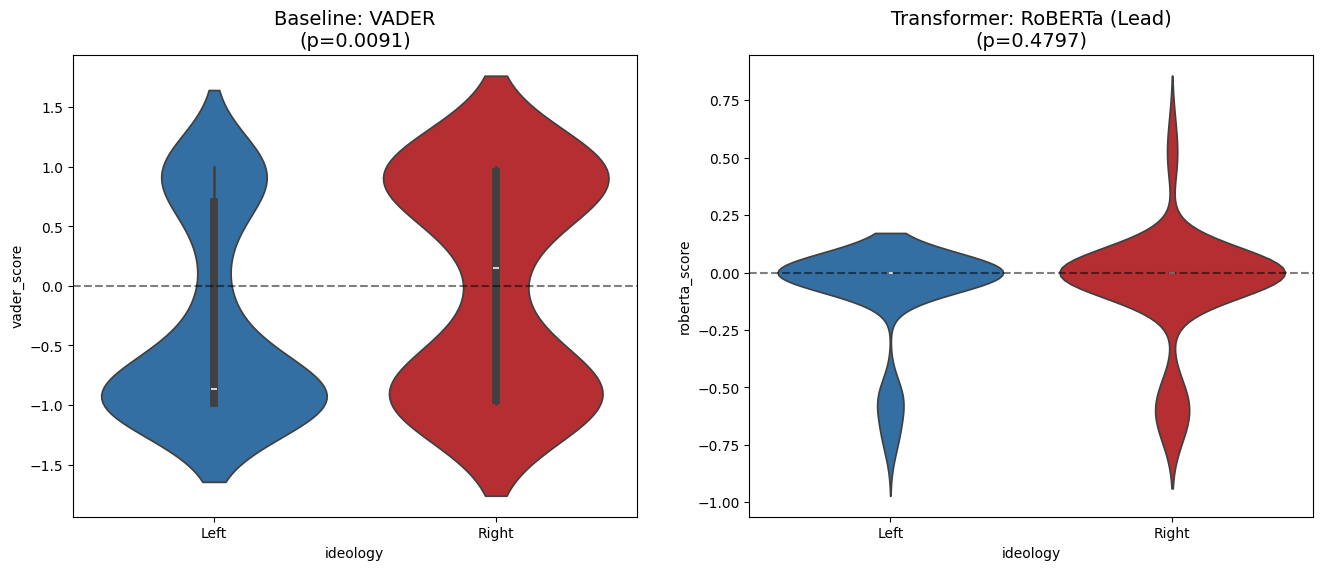

In [12]:
# 4. Visualization

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# VADER Violin
sns.violinplot(data=df_clean, x='ideology', y='vader_score', ax=axes[0],
               palette=['#2171b5', '#cb181d'], hue='ideology',legend=False, density_norm="area")       # The density_norm parameter is for each violin to have the same area for easy comparison
axes[0].set_title(f'Baseline: VADER\n(p={p_vader:.4f})', fontsize=14)
axes[0].axhline(0, color='k', linestyle='--', alpha=0.5)

# RoBERTa Violin
sns.violinplot(data=df_clean, x='ideology', y='roberta_score', ax=axes[1], 
                palette=['#2171b5', '#cb181d'], hue='ideology',legend=False, density_norm="area")      # The density_norm parameter is for each violin to have the same area for easy comparison
axes[1].set_title(f'Transformer: RoBERTa (Lead)\n(p={p_roberta:.4f})', fontsize=14)
axes[1].axhline(0, color='k', linestyle='--', alpha=0.5)

plt.show()



## Understanding our plots

**1. Significance (P-Value):**
*   If **p < 0.05**: The difference in sentiment between Left and Right is **real**, not random chance.
*   If **p > 0.05**: We cannot claim a difference in tone.

**2. Distribution Shape (The Violin):**
*   **Fat middle:** Most articles are neutral.
*   **Fat bottom:** Heavy negative framing (fear/anger).
*   **Fat top:** Positive framing (celebration/support).
*   **The Median** of the distribution is indicated by a white dot.


## Interpretation

**VADER Analysis (Lexicon-Based)**
*   **Statistical Signal:** The p-value ($0.0091$) confirms a significant divergence in sentiment distribution.
*   **Shape:** Both ideologies display **bimodal distributions** (distinct "bulbs" at positive and negative extremes), characteristic of VADER's binary scoring tendencies. However, the **Left (Blue)** is distinctly bottom-heavy, indicating a dominance of negative vocabulary ("crisis," "concern"). The **Right (Red)** is more balanced, with a larger upper bulb representing positive vocabulary ("justice," "victory").
*   **Median:** The shift is visible in the white dots. The Left's median sits in the negative range, while the Right's median crosses the zero-threshold into positive territory, confirming the Right used more celebratory language.

**RoBERTa Analysis (Context-Aware)**
*   **Statistical Signal:** The high p-value ($0.4797$) indicates **no statistical difference** between the two narratives.
*   **Shape:** Both distributions are **unimodal** and highly compressed around the neutral axis ($0.0$), resembling inverted "T" shapes. The "long tails" extending downward show that negative sentiment exists as an outlier, not the norm.
*   **Median:** Both white dots are identical and centered at zero. This proves that once context is accounted for, the "emotional gap" disappears; both sides employed a standard, neutral journalistic tone in their opening paragraphs.

**Synthesis:** The difference between the plots highlights **lexical bias vs. tonal reality.** The Left and Right used different *words* (triggering VADER), but wrote with the same *professional detachment* (detected by RoBERTa).  

We thought this was a really interesting finding, so, to further visualize this contradiction, we will plot normalized distribution plots (Kernel Density Estimates or KDEs).  These allow us to overlay the Left and Right distributions directly on top of each other to see exactly where they diverge. 


## Comparative Distribution Analysis (VADER vs. RoBERTa)

As explained, we want to overlay the sentiment distributions to visualize better understand why VADER found a difference while RoBERTa did not.  
We plot  **Normalized KDE Plots:** These show the "shape" of the sentiment. Overlapping areas indicate agreement between ideologies.  

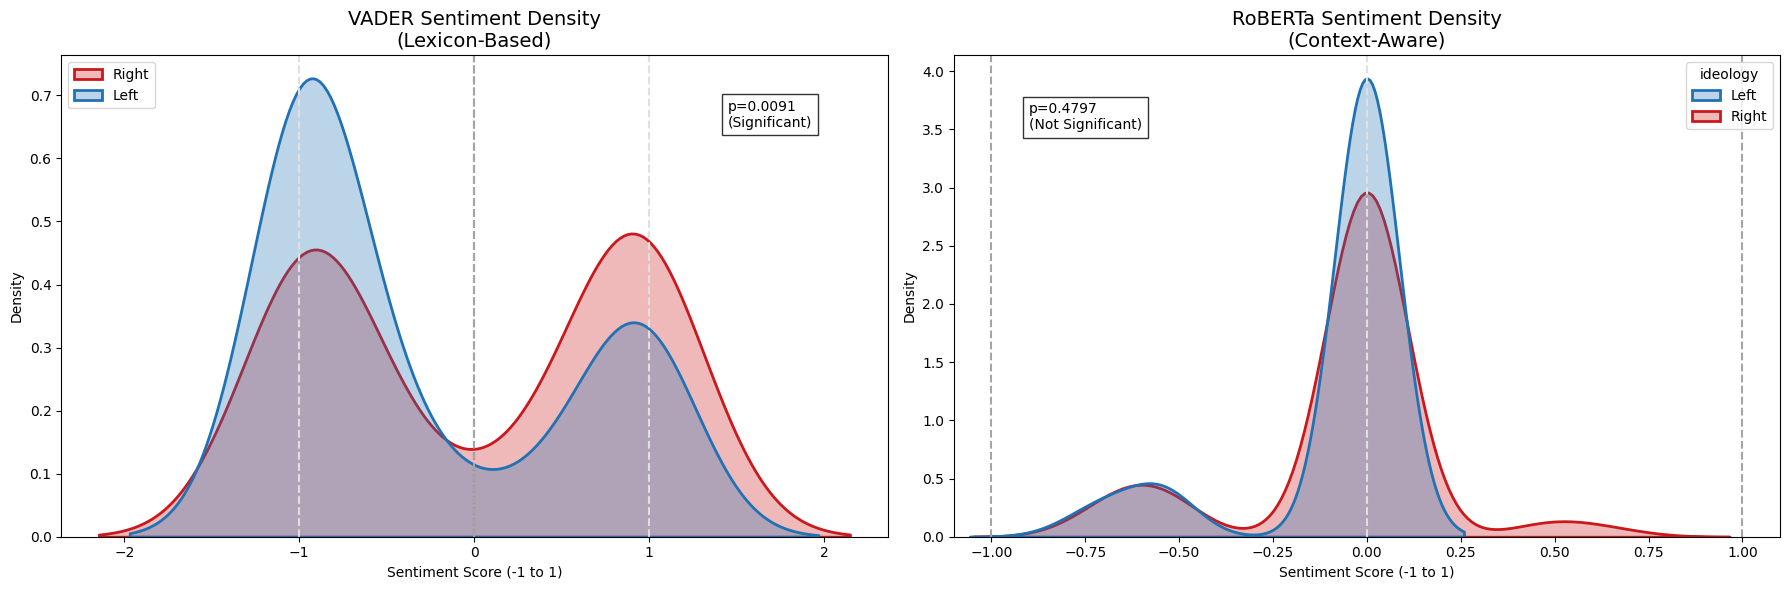

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=False, sharey=False)

# Define standard colors
colors = {'Left': '#2171b5', 'Right': '#cb181d'}

# Plot 1: VADER Distributions 
sns.kdeplot(
    data=df_clean, 
    x='vader_score', 
    hue='ideology', 
    palette=colors, 
    fill=True, 
    alpha=0.3, 
    linewidth=2,
    ax=axes[0],
    common_norm=False # By default, Seaborn scales the curves relative to the total dataset size. We want to account for the class imbalance, so the area under EACH curve equals 1 << As prof remarqued
)

axes[0].set_title(f'VADER Sentiment Density\n(Lexicon-Based)', fontsize=14)
axes[0].set_xlabel('Sentiment Score (-1 to 1)')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[0].legend(labels=['Right', 'Left'], loc='upper left')

# Plot 2: RoBERTa Distributions 
sns.kdeplot(
    data=df_clean, 
    x='roberta_score', 
    hue='ideology', 
    palette=colors, 
    fill=True, 
    alpha=0.3, 
    linewidth=2,
    ax=axes[1],
    common_norm=False # By default, Seaborn scales the curves relative to the total dataset size. We want to account for the class imbalance, so the area under EACH curve equals 1 << As prof remarqued
)
axes[1].set_title(f'RoBERTa Sentiment Density\n(Context-Aware)', fontsize=14)
axes[1].set_xlabel('Sentiment Score (-1 to 1)')

# Interpretive Annotation based on your p-values
axes[0].text(1.45, 0.65, f"p={p_vader:.4f}\n(Significant)", bbox=dict(facecolor='white', alpha=0.8))
axes[1].text(-0.9, 3.5, f"p={p_roberta:.4f}\n(Not Significant)", bbox=dict(facecolor='white', alpha=0.8))

# Add some lines for easy reading
axes[0].axvline(0, color="#A5A5A5", linestyle='--')
axes[0].axvline(-1, color='#E0E0E0', linestyle='--')
axes[0].axvline(1, color='#E0E0E0', linestyle='--')
axes[1].axvline(0, color='#E0E0E0', linestyle='--')
axes[1].axvline(-1, color='#A5A5A5', linestyle='--')
axes[1].axvline(1, color='#A5A5A5', linestyle='--')

plt.xlim(-1.1, 1.1)
plt.tight_layout()
plt.show()


Note that we again accounted for the class imbalance by setting common_norm=False, so the area under EACH curve equals 1.

## Interpretation:  
As we found in the violin plots, 
1.  **VADER (Left Plot):** We see the Blue curve (Left) clearly shifted to the left (more negative) compared to the Red curve. This confirms the p-value: the Right is using "happier" vocabulary (e.g., "victory", "justice") while the Left uses "cautious" vocabulary.
2.  **RoBERTa (Right Plot):** The curves overlap very closely, although we observe the longer tail on the right-end (positive) for the Red curve (Right). This suggests that despite using different words, the actual *journalistic tone* is standard "serious news" across the board.  

## Conclusion
Lexicon models (VADER) are biased by specific keywords, whereas Transformer models (RoBERTa) see past the keywords to the actual meaning.

Example:
"Venezuelan authorities confirmed the capture of Nicolás Maduro following negotiations with military leadership. He was transferred to a secure facility pending legal proceedings."
- VADER:  sees “capture” → negative, “authorities” / “secure facility” → punitive, “pending legal proceedings” -> negative institutional framing = scores negative
- RoBERTa: sees no evaluative adjectives (“brutal”, “triumphant”), no affective stance by the journalist = neutral score

# Part 4: Topic Modeling (The "Framing" Analysis)


Beyond observing the "how" of the Right/Left framing, we wish to answer the "Why" (Topics).  
To do that, we will implement Topic Modeling.

We chose to use **NMF (Non-Negative Matrix Factorization)** instead of LDA, because LDA assumes documents are mixtures of topics (probabilistic) whereas  
NMF is better at identifying *distinct* topics for news articles, which is better for detecting specific "frames" (like "Human Rights" vs "Drug Trafficking").

## Methodology: NMF (Non-Negative Matrix Factorization)
*   **Preprocessing:** We filter the text to keep only **Nouns** and **Adjectives**. This removes generic action verbs ("said", "went") and focuses on the *subjects* and their *descriptors*.
*   **Metric:** We calculate the "Topic Share" which reprensents what percentage of the Left's coverage is devoted to Topic A vs Topic B


In [14]:
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import numpy as np
!pip install spacy
!python3 -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 4.2 MB/s  0:00:03m0:00:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [15]:
# Load Spacy for POS Tagging 
try:
    nlp = spacy.load("en_core_web_sm")
except:
    print("Downloading Spacy model...")
    import os
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

def filter_nouns_adjs(text):
    """Keep only nouns and adjectives to sharpen topics."""
    doc = nlp(text)
    return " ".join([token.text for token in doc if token.pos_ in ['NOUN', 'ADJ']])

print("\n-- Preprocessing for Topic Model (POS Tagging)... --")
# This might take a minute (usually 30sec)
df_clean['topic_text'] = df_clean['clean_text'].apply(filter_nouns_adjs)


# 1. Vectorization (TF-IDF) (with bigrams enabled)
tfidf = TfidfVectorizer(
    max_features=2000, 
    max_df=0.95,
    min_df=2,
    stop_words=custom_stop_words, # Re-using our aggressive list from Part 2
    ngram_range=(1, 2) # allow "International Law" or "Drug Trafficking"
)
X = tfidf.fit_transform(df_clean['topic_text'])


# ----- This sub-part is just to visualize an example of document vector as requested in instructions

print("\n-- Example of Document Vector (First Article) --")
# We visualize what TFIDF has computed: a sparse vector of weights that represents an article
feature_names = tfidf.get_feature_names_out()
first_doc_vector = X[0] # article choice

# Convert to readable dataframe
df_vector = pd.DataFrame(
    first_doc_vector.T.todense(),   # this filters out the Zeros just so our apercu will show non-zero weights
    index=feature_names, 
    columns=["TF-IDF Score"]
)
print(df_vector[df_vector["TF-IDF Score"] > 0].sort_values("TF-IDF Score", ascending=False).head(10))

# -----

# 2. Run NMF
NUM_TOPICS = 3
nmf = NMF(n_components=NUM_TOPICS, random_state=42)
W = nmf.fit_transform(X) # Document-Topic Matrix
H = nmf.components_      # Topic-Term Matrix


# 3. Extract & Label Topics
feature_names = tfidf.get_feature_names_out()
topic_labels = []

print ('done')
print("\n-- Discovered Topics --")
for topic_idx, topic in enumerate(H):
    top_indices = topic.argsort()[:-6:-1]
    top_words = [feature_names[i] for i in top_indices]

    # Create a label for the graph
    label = f"Topic {topic_idx+1}: {', '.join(top_words)}"
    topic_labels.append(f"T{topic_idx+1} ({top_words[0]}, {top_words[1]}, {top_words[2]})")
    print(label)

# Assign dominant topic to each article
df_clean['topic'] = W.argmax(axis=1)


# ----- This sub-part is just to return a SPSS table for the Topic weights, as suggested in feedback to the class

# Document–Topic matrix: an SPSS-style table
print("\n-- Document–Topic matrix --\n")
spss_table = pd.DataFrame(
    W,
    columns=[f"topic_{i+1}" for i in range(NUM_TOPICS)]
)

# Add metadata
spss_table["dominant_topic"] = W.argmax(axis=1) + 1
spss_table["ideology"] = df_clean["ideology"].values

print(spss_table.head())

# -----


-- Preprocessing for Topic Model (POS Tagging)... --

-- Example of Document Vector (First Article) --
                   TF-IDF Score
sources                0.187530
team                   0.174509
operation              0.168908
strike                 0.167202
president              0.154833
weather                0.148277
ahead                  0.140722
familiar plans         0.140722
timeline               0.140722
national security      0.129119
done

-- Discovered Topics --
Topic 1: president, country, oil, international, administration
Topic 2: cocaine, indictment, drug, conspiracy, narco
Topic 3: military, operation, aircraft, explosions, helicopters

-- Document–Topic matrix --

    topic_1   topic_2   topic_3  dominant_topic ideology
0  0.072028  0.000000  0.341668               3     Left
1  0.157185  0.000000  0.064132               1     Left
2  0.190127  0.000000  0.000000               1     Left
3  0.127553  0.000000  0.000000               1     Left
4  0.204373  0.02

**Example of Document Vector**  

-> Above, you see an example of how an article appears to the model after applying TF-IDF.  Instead of raw text, the document is now a vector of weighted scores.  
A high score means the word is statistically significant for this specific article compared to the rest of the dataset (eg, "cocaine" has a high weight, while common words have zero). 

**SPSS Table of Document-Topic matrix**  

-> As suggested in the feedback, we included a sneak peak of what the Topic Weights Matrix looks like.  

We continue with the plotting of our Topic Modeling.


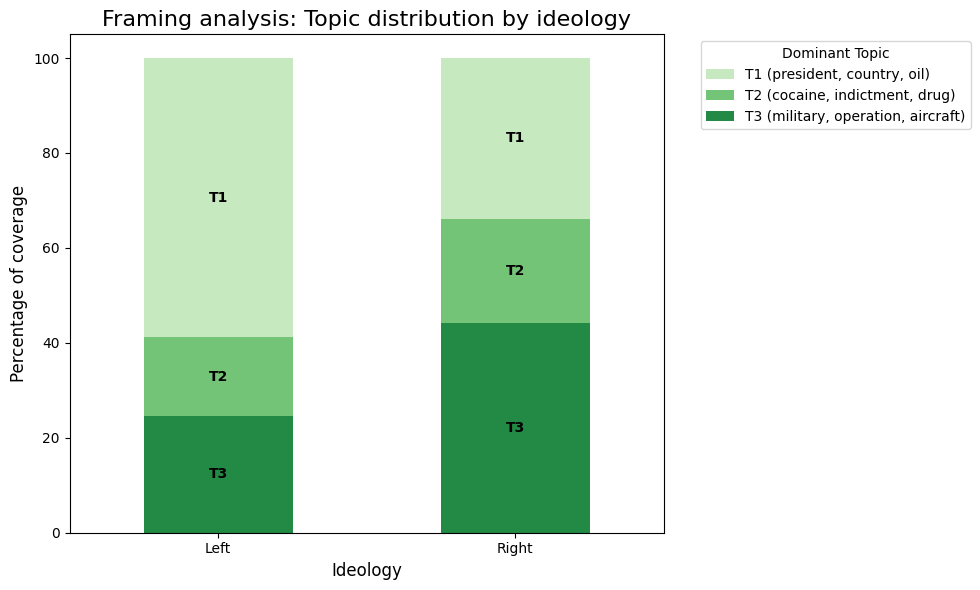

In [16]:
# 4. Visualization: Topic Share by Ideology
topic_counts = df_clean.groupby(['ideology', 'topic']).size().unstack(fill_value=0)
topic_props = topic_counts.div(topic_counts.sum(axis=1), axis=0) * 100

# Reverse data so Topic 1 is plotted last (on top of the stack)
topic_props = topic_props.iloc[:, ::-1]
# Reverse palette to match (Dark green T1 on top)
auto_palette = sns.color_palette("Greens", n_colors=NUM_TOPICS)[::-1]

ax = topic_props.plot(kind='bar', stacked=True, color=auto_palette, figsize=(10, 6))

# Add Labels (Iterating through containers matches the bottom-up plot order T5->T1) // got help with documentation for that
for container, label in zip(ax.containers, topic_labels[::-1]):
    # Add 'T1' etc if segment is > 3% height
    labels = [label.split()[0] if v > 3 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', fontweight='bold', color='black')

# Fix Legend: Reverse handles so T1 (Top bar) is at Top of Legend
handles, _ = ax.get_legend_handles_labels()
plt.legend(handles[::-1], topic_labels, title='Dominant Topic', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Framing analysis: Topic distribution by ideology', fontsize=16)
plt.ylabel('Percentage of coverage', fontsize=12)
plt.xlabel('Ideology', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Interpretation
This confirms the framing hypothesis:

1. Left-Wing framing:
The Left is dominated by Topic 1 ("President, Country, Oil"), which accounts for ≈60% of their coverage.  
This suggests a focus on geopolitics and sovereignty, ie a **procedural framing**. They are likely discussing the implications for Venezuela and energy markets rather than the tactical details of the capture.
2. Right-Wing framing:
The coverage on the RIght is more driven by Topic 3 ("Military, Operation"), which accounts for ≈40% of their coverage. Topic 2 ("Cocaine, Indictment") is also more prevalent than on the Left.
They suggests that they frame the event as a law enforcement victory and a military success, focusing on the action (helicopters/raid) and the justification (drugs, oil), while minimizing the "Presidential" or diplomatic context found in T1. This is more of a **criminality & security framing**.  

Conclusion: To caracterize, the Left sees a political crisis; the Right sees a drug bust.

## Convergence or Polarization?

In [17]:
# We look at the highest weight in the W matrix for each article, to interpret the intensity of the framing
df_clean['framing_confidence'] = W.max(axis=1)
focus_score = df_clean.groupby('ideology')['framing_confidence'].mean()

print("\n-- Framing Confidence --")
print(focus_score)

# We calculate the spread from the topic_props table, to interpret the Polarization Gap
gap_t1 = topic_props.loc['Left', 0] - topic_props.loc['Right', 0] # for Topic 1
gap_t3 = topic_props.loc['Right', 2] - topic_props.loc['Left', 2] # for Topic 3

print(f"\n-- Polarization Metrics --")
print(f"Left's Monopoly on T1 (Procedural): +{gap_t1:.1f}%")
print(f"Right's Monopoly on T3 (Militarist): +{gap_t3:.1f}%")


-- Framing Confidence --
ideology
Left     0.189050
Right    0.187617
Name: framing_confidence, dtype: float64

-- Polarization Metrics --
Left's Monopoly on T1 (Procedural): +24.9%
Right's Monopoly on T3 (Militarist): +19.6%


## Interpretation

1. Discipline (Convergence):
The nearly identical scores indicate that both sides are equally consistent/rigid on their narrative.  
Neither ideology is more open-minded or scattered than the other.

2. Symmetrical Polarization:
They are mirror images. The Left "owns" the Procedural Frame (T1) by a margin of 25%, while the Right "owns" the Militarist Frame (T3) by 20%.  
They are talking of their prefered topic with similar intensity. This symmetrical polarization suggests a shared reality but mutually exclusive interpretations.  


# Part 5: Named Entity Recognition (NER)


Having observed the surfacing topics of the Right/Left framing, we wish to answer the "Who" (Entities).  
Lexicon analysis tells us *what* words they use. Sentiment tells us *how* they feel. NER tells us *who* they blame or credit.  

**Goal:** Identifying the "Protagonists".  
To do that, we will implement Entity recognition with Spacy. 

## Methodology: The "Protagonist" Check
*   **Model:** Spacy Named Entity Recognition. It detects specific proper nouns and classifies them (e.g., PERSON, ORG, GPE (Geo-Political Entity, eg country or state)).
*   **Hypothesis:** 
    *   Right-wing media will personalize more the victory (Flores, Rubio).
    *   Left-wing media will institutionalize more the event (mentions of UN, ICC, DOJ).

* **Adjustments in preprocessing:**  
Spacy uses raw, case-sensitive text with punctuation. So, we are not supposed to lowercase or strip punctuation before passing text to Spacy, otherwise it will fail to detect entities (e.g., "white house" is a building, "White House" is an Org). However, this created some issues:
    * During our initial tries, Spacy was making mistakes (eg, labeling Trump or Getty Images as Organizations).  
    -> We thus forced-filter these out using ban lists (with one global and one specific for entities) and people_as_orgs_fix (force mapping).
    * During our initial tries, Spacy was counting similiar entities as distinct (eg, Trump vs Donal Trump). Also, SpaCy handles accents but does not merge things like (Nicolas, Nicolás).  
    -> We could not reuse ffty (from part1) because this only fixes encoding errors (eg merging NicolÃ¡s with Nicolás). Wethus implemented a entity_map to fix it. 
Also, we removed high-frequency terms like "Venezuela", "US", "Trump", "Maduro" because they appear in 100% of articles and as such do not bring any interesting value.

## Visualisation choice
We use a **Population Pyramid** visualization (often used in demographics).
*   **Metric:** Mentions per 100 Articles (Normalized). This is crucial because we have more Left-wing articles; raw counts would be misleading.
*   **Center:** Entities appearing equally on both sides (Consensus).
*   **Edges:** Entities skewed heavily to one side (Partisan focus).



In [18]:
import spacy
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

# Load Spacy
# We use the small model ('en_core_web_sm') for speed. 
# the Transforemer model would be more accurate but slower.
try:
    nlp = spacy.load("en_core_web_sm")
except:
    import os
    os.system("python -m spacy download en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

# 1. Configuration: The Dictionary of Truth

# DATA CLEANING: Normalization Dictionary
# We map variations to a unique name to prevent demultiplication in our stats.
entity_map = {
    # People
    'Rubio': 'Marco Rubio', 'Sen. Rubio': 'Marco Rubio',
    'Biden': 'Joe Biden', 'President Biden': 'Joe Biden',
    'Rodriguez': 'Delcy Rodríguez', 'Delcy': 'Delcy Rodríguez',
    'Guaido': 'Juan Guaidó',
    'Machado': 'María Corina Machado', 'María Corina': 'María Corina Machado',
    'Flores': 'Cilia Flores',
    'Lee': 'Mike Lee', 'Sen. Lee': 'Mike Lee', 
    'Rodriguéz': 'Delcy Rodríguez',
    # Orgs
    'UN': 'United Nations',
    'GOP': 'Republican Party',
    'the White House':'White House',
    'DOJ': 'Department of Justice', 'Justice Department': 'Department of Justice',
    'the Department of Justice':'Department of Justice',
    'Central Intelligence Agency': 'CIA'
}

# STOPWORDS / NOISE REMOVAL
# We remove high-frequency terms (like "Venezuela", "US", "Trump", "Maduro") because they appear in 100% of articles
ban_list = {
    'Trump','Donald Trump', 'Mr. Trump','Donald Trump','president Trump', 
    'Getty', 'Images', 'Reuters', 'AP', 'AFP', 'Fox', 'CNN', # Agency/source noise
    'Maduro', 'Nicolás Maduro', 'Nicolas Maduro', 'Venezuela','Caracas', # The topic itself
    'U.S.', 'US', 'USA', 'America', 'Washington', 'Miami', 'the United States','New York', # Generic geographies
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', # Temporal noise
    'Caine', 'Post', 'State', 'X.', 'Destructive Devices',
    'Getty Images', 'Truth Social', 'Fox News', 'The New York Times', 
    'Post', 'State', 'caine', 'Suns', 'NYC','the New York Times', 'La Carlota', 'REUTERS',
    'Cocaine Importation Conspiracy' # Spacy thought this was a person/org....
}

# NER CORRECTION LIST
# Spacy often miscategorizes famous people as Organizations (e.g., "The Trump Organization" vs "Trump"). We force-exclude these.
people_as_orgs_fix = [
    'María Corina Machado', 
    'Rodríguez', 'Cilia Flores', 'Marco Rubio',
    'the Joint Chiefs of Staff', 'Joint Chiefs of Staff',
]

def clean_entity(text):
    """
    Standardizes entity names and removes noise.
    """
    text = text.strip().replace("’s", "").replace("'s", "")
    # Filter out banned words or short garbage strings
    if text in ban_list or len(text) < 3: return None
    # Return the mapped name if it exists, else the original
    return entity_map.get(text, text)

# 2. Extraction & Normalization

def get_entity_stats(label_type, top_n=15):
    """
    1. Split corpus by ideology.
    2. Extract entities using Spacy NER.
    3. Normalize counts by corpus size (Mentions per 100 articles).
    """
    left_corpus = df_clean[df_clean['ideology'] == 'Left']['clean_text']
    right_corpus = df_clean[df_clean['ideology'] == 'Right']['clean_text']

    def count_docs(corpus): # This fct had to be built inside bc
        c = Counter()
        # pipe() is faster than calling nlp() on each text individually, and disable=["parser"] speeds things up as we only need NER tags.
        for doc in nlp.pipe(corpus, disable=["parser"]): 
            for ent in doc.ents:
                # Check if tag matches requested types (eg ORG)
                if ent.label_ == label_type:
                    clean = clean_entity(ent.text)
                    
                    # Special cse If looking for ORGs, ensure it's not a misclassified Person
                    if ent.label_ == 'ORG' and clean in people_as_orgs_fix:
                        continue
                    
                    if clean: c[clean] += 1
        return c

    print(f"-- Processing {label_type}... --")
    l_counts = pd.Series(count_docs(left_corpus), name='Left')
    r_counts = pd.Series(count_docs(right_corpus), name='Right')

    # Combine and fill zeros (case when an entity is mentioned on Left but never on Right)
    df = pd.concat([l_counts, r_counts], axis=1).fillna(0)
    
    # CRITICAL STATISTICAL STEP: Normalization
    # We convert to "Mentions per 100 articles" to compare (account for class imbalance)).
    df['Left_Norm'] = (df['Left'] / len(left_corpus)) * 100
    df['Right_Norm'] = (df['Right'] / len(right_corpus)) * 100
    
    # Sort by sum of frequency descending to find the most relevant entities overall
    df['Total'] = df['Left_Norm'] + df['Right_Norm']
    return df.sort_values('Total', ascending=True).tail(top_n)

# Execution: we generate 3 separate dataframes
df_people = get_entity_stats('PERSON', top_n=10)
df_gpe = get_entity_stats('GPE', top_n=10)
df_orgs = get_entity_stats('ORG', top_n=10)
print('Done.')



-- Processing PERSON... --
-- Processing GPE... --
-- Processing ORG... --
Done.


/var/folders/4w/5xh4p2d91wdc6mw9hknkhmgm0000gn/T/ipykernel_7084/3633048206.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(int(x))}' for x in ticks])
/var/folders/4w/5xh4p2d91wdc6mw9hknkhmgm0000gn/T/ipykernel_7084/3633048206.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(int(x))}' for x in ticks])
/var/folders/4w/5xh4p2d91wdc6mw9hknkhmgm0000gn/T/ipykernel_7084/3633048206.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(int(x))}' for x in ticks])


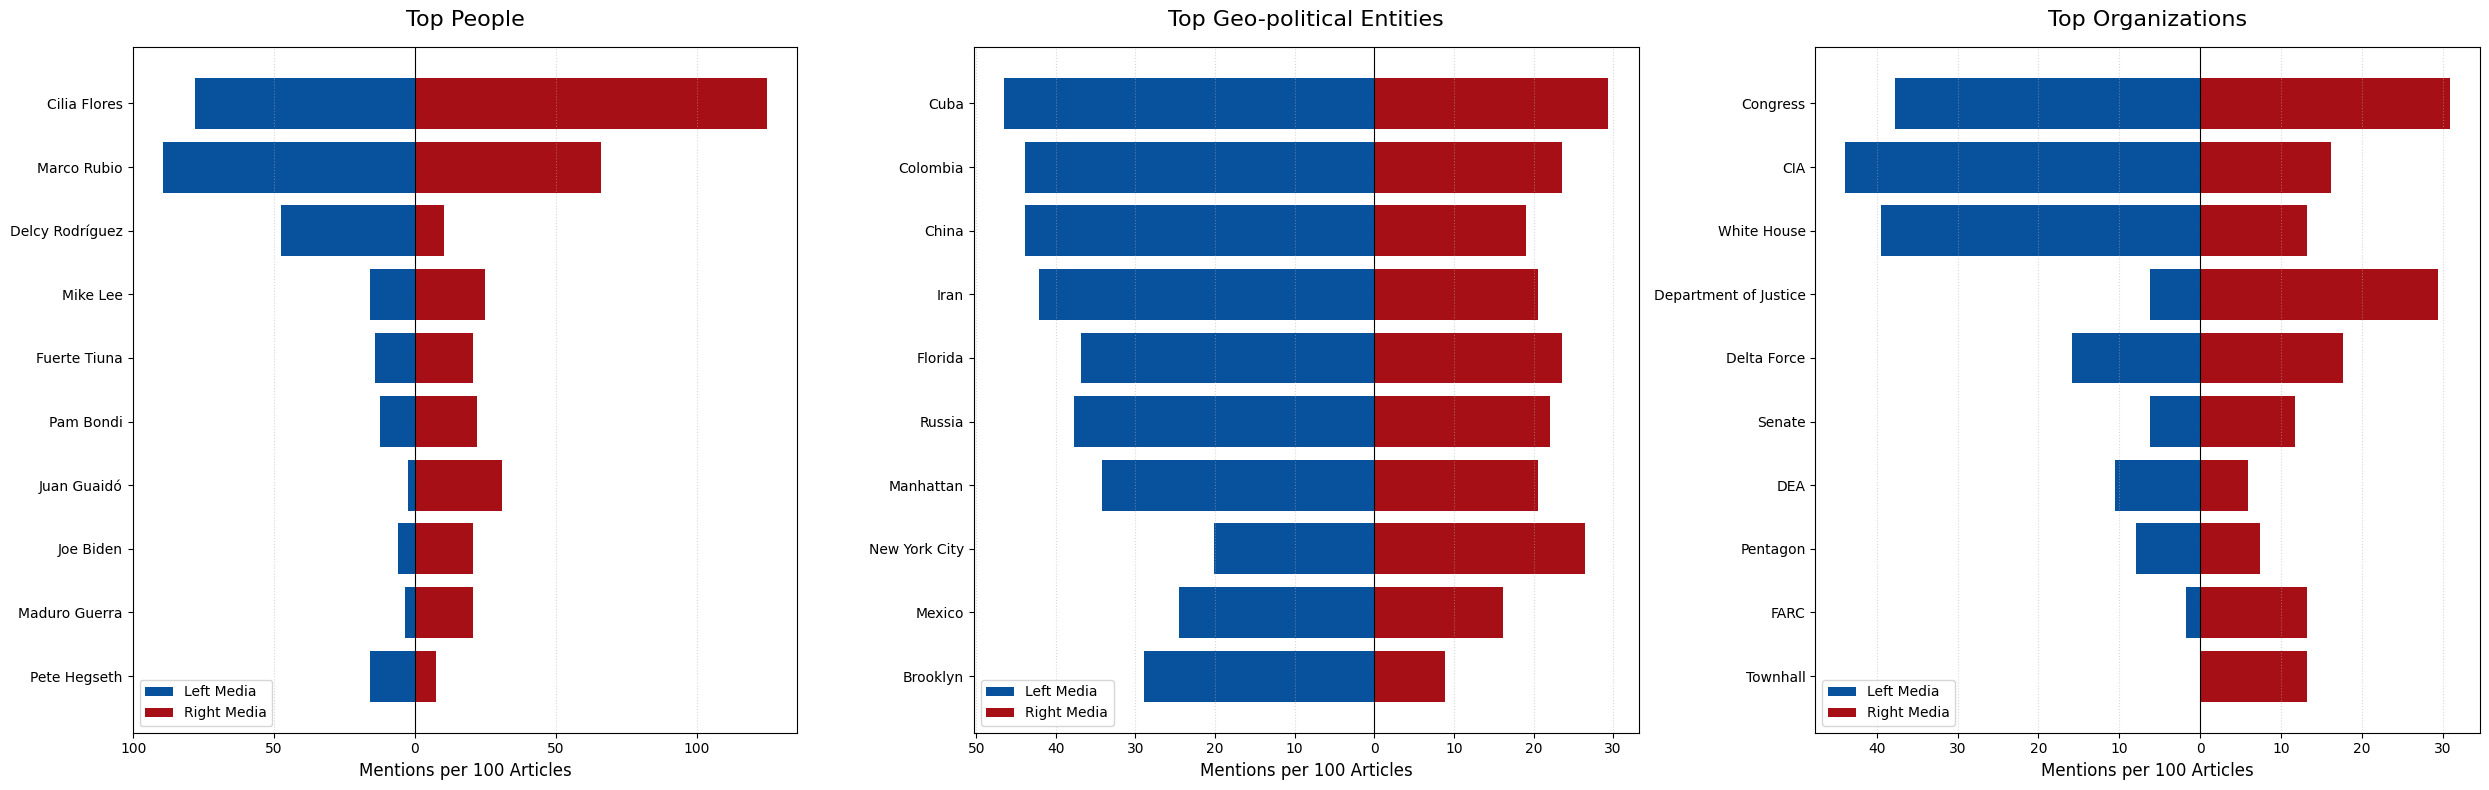

In [19]:
# 3. Visualization:
# Using a 3-column layout to compare People, Places, and Institutions side-by-side
fig, axes = plt.subplots(1, 3, figsize=(25, 8))
plt.subplots_adjust(wspace=0.4) # Add spaces between plots for readability

def plot_butterfly(df, ax, title):
    # We make Left values negative to make them go to the left side of the Y-axis
    ax.barh(df.index, -df['Left_Norm'], color='#08519c', label='Left Media')
    ax.barh(df.index, df['Right_Norm'], color='#a50f15', label='Right Media')
    
    # Center line for visual clarity
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=16, pad=15)
    ax.set_xlabel('Mentions per 100 Articles', fontsize=12)
    
    # We want the x-axis to show positive numbers for the left also, so we replace labels (eg -10) with absolute values (10).
    ticks = ax.get_xticks()
    ax.set_xticklabels([f'{abs(int(x))}' for x in ticks])
    
    ax.grid(axis='x', linestyle=':', alpha=0.5)
    ax.legend()

# Map the dataframes to specific subplots
plot_butterfly(df_people, axes[0], "Top People")
plot_butterfly(df_gpe, axes[1], "Top Geo-political Entities")
plot_butterfly(df_orgs, axes[2], "Top Organizations")

plt.tight_layout()
plt.show()

## Interpretation

**1. Persons**
The **Left** focuses on **Marco Rubio**, likely framing him as the architect of the policy. The **Right** focuses intensely on **Cilia Flores** (Maduro's wife), probably framing the regime not as a government, but as a "crime family", as is exposed in the DOJ "United States v. Nicolás Maduro Moros" prosecution explanation.

**2. Geo-political Entities**
The presence of **Manhattan, Brooklyn, and New York City** alongside global adversaries (**Cuba, China, Iran**) suggests that the media is treating this event simultaneously as a global geopolitical crisis and a local New York legal drama (NY courts).

**3. Organizations**
*   **Right Skew:** **DOJ, Delta Force, FARC**. The Right frames this as a military/law enforcement operation against narco-terrorism. 
*   **Left Skew:** **CIA, White House, Congress**. The Left frames this through the lens of intelligence failures and legislative oversight.